# TASK 3

# Customer Churn Prediction



**Models compared:** Logistic Regression, Random Forest, Gradient Boosting

**Dataset:** `Churn_Modelling.csv` (Bank Customer Churn dataset from Kaggle)

## Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Set a consistent random state so results are reproducible
RANDOM_STATE = 42

## Step 2: Load the dataset

In [2]:
df = pd.read_csv("/content/Churn_Modelling.csv")

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (10000, 14)


## Step 3: Drop columns that are not useful for prediction

`RowNumber`, `CustomerId`, and `Surname` are just identifiers. They don't carry any real information about churn behavior.

In [4]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

## Step 4: Handle missing values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# Fill missing numeric columns with the median value
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical columns with the most frequent value (mode)
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

## Step 5: Quick look at churn distribution (target variable)

In [8]:
print("Churn value counts (0 = Stayed, 1 = Exited):")
print(df["Exited"].value_counts())

Churn value counts (0 = Stayed, 1 = Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64


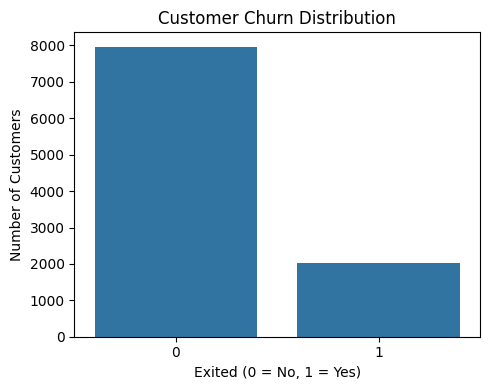

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Step 6: Encode categorical columns

`Geography` and `Gender` are text columns, so we convert them to numbers. `LabelEncoder` turns each category into an integer code.

In [10]:
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Data after encoding categorical columns:")
df.head()

Data after encoding categorical columns:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Step 7: Split data into features (X) and target (y)

In [11]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

# Split into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 10)
Testing set size: (2000, 10)


## Step 8: Feature scaling

Scaling makes all features have similar ranges. This mainly helps Logistic Regression converge well.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 9: Helper function to train, evaluate, and plot a model

In [13]:
def evaluate_model(model, model_name, X_train_data, X_test_data):
    """Train the given model and print/plot its evaluation results."""

    # Train the model
    model.fit(X_train_data, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_data)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")

    # Print detailed classification report (precision, recall, f1-score)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Compute and plot the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Churned", "Churned"],
                yticklabels=["Not Churned", "Churned"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return acc

## Step 10: Train and evaluate Logistic Regression

===== Logistic Regression =====
Accuracy: 0.8050

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



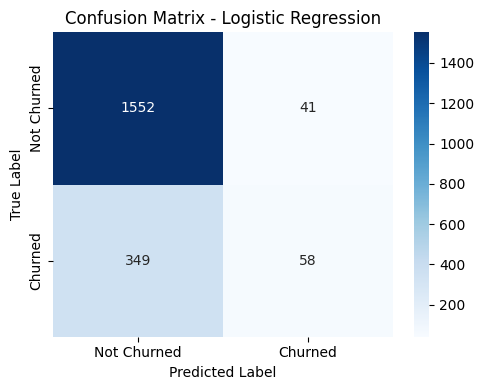

In [14]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
acc_log_reg = evaluate_model(
    log_reg, "Logistic Regression", X_train_scaled, X_test_scaled
)

## Step 11: Train and evaluate Random Forest

Tree-based models don't need feature scaling, so we use the original (unscaled) training and testing data.

===== Random Forest =====
Accuracy: 0.8640

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



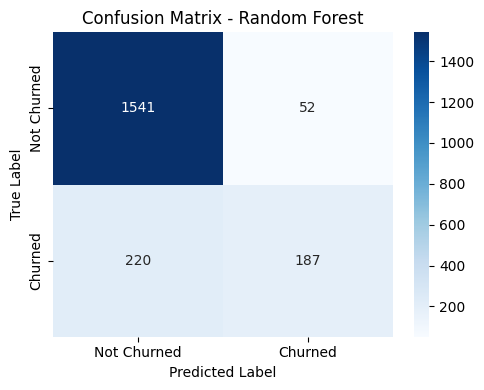

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
acc_rf = evaluate_model(
    rf_model, "Random Forest", X_train, X_test
)

## Step 12: Train and evaluate Gradient Boosting

===== Gradient Boosting =====
Accuracy: 0.8675

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



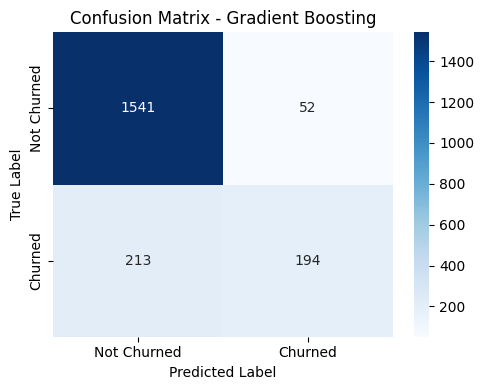

In [16]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
acc_gb = evaluate_model(
    gb_model, "Gradient Boosting", X_train, X_test
)

## Step 13: Compare all models

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [acc_log_reg, acc_rf, acc_gb]
})

print("Model Comparison:")
results.sort_values(by="Accuracy", ascending=False)

Model Comparison:


,Model,Accuracy
2,Gradient Boosting,0.8675
1,Random Forest,0.8640
0,Logistic Regression,0.8050


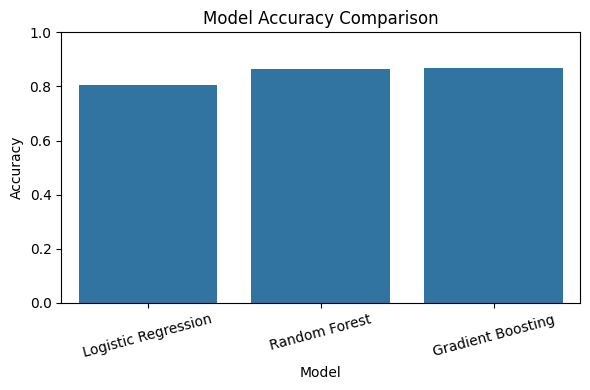

In [18]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 14: Feature importance (from Random Forest)

This shows which features matter most for predicting churn.

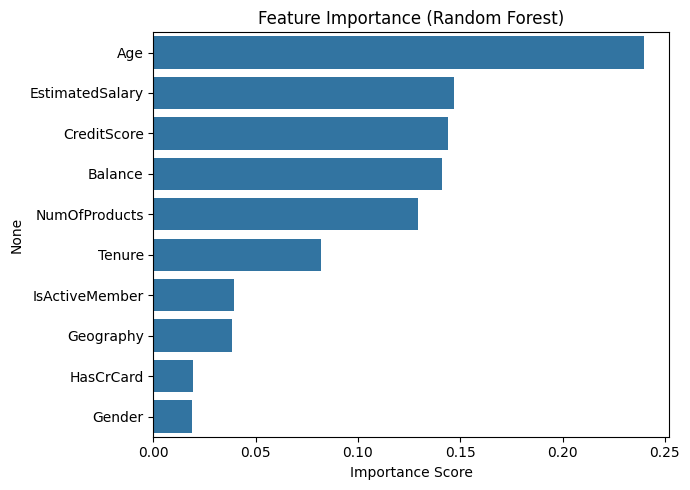

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()